In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import shap
import joblib
from pathlib import Path
from itertools import product
 
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, GridSearchCV,
    cross_val_score, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    roc_curve, matthews_corrcoef
)
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.calibration import calibration_curve
 
OUTPUT_PATH = Path("outputs2/figures")
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
 

In [4]:
# Load data 
full_features = pd.read_csv("data/final_sequence_dataset_features.csv")
df_labels     = pd.read_csv("data/Dataset_gbm.csv")
 
df_features_clean = full_features.drop_duplicates(subset=['UniProt ID', 'Mutation'])
df_labels_clean   = df_labels.drop_duplicates(subset=['UniProt ID', 'Mutation'])
 
df_final = pd.merge(
    df_features_clean,
    df_labels_clean[['UniProt ID', 'Mutation', 'Class']],
    on=['UniProt ID', 'Mutation'],
    how='inner'
)
print(f"Dataset after merge : {len(df_final)} mutations")
print(df_final['Class'].value_counts())
 
# Subclass split
df_alpha = df_final[df_final['secondary_structure'] == 0].copy()
df_beta  = df_final[df_final['secondary_structure'] == 1].copy()
df_coil  = df_final[df_final['secondary_structure'] == 2].copy()
print(f"\nAlpha : {len(df_alpha)} | Beta : {len(df_beta)} | Coil : {len(df_coil)}")
 
 
# ── Cell 3 : Feature/target preparation ──────────────────────────────────────
META_COLS = [
    'UniProt ID', 'Gene Name', 'Mutation', 'Wild', 'Mut', 'Pos',
    'Class', 'secondary_structure', 'nM', 'Mc', 'tri',
    'n_M', 'M_c', 'n__M', 'M__c'
]
 
def prepare_Xy(df):
    y = df['Class'].map({'Driver': 1, 'Passenger': 0})
    X = df.drop(columns=[c for c in META_COLS if c in df.columns])
    return X, y
 
X_alpha, y_alpha = prepare_Xy(df_alpha)
X_beta,  y_beta  = prepare_Xy(df_beta)
X_coil,  y_coil  = prepare_Xy(df_coil)
feature_names = X_alpha.columns  # same for all 3 subclasses

Dataset after merge : 16907 mutations
Class
Passenger    8703
Driver       8204
Name: count, dtype: int64

Alpha : 4212 | Beta : 1931 | Coil : 10764


In [5]:
# ── Cell 3 : Feature/target preparation ──
META_COLS = [
    'UniProt ID', 'Gene Name', 'Mutation', 'Wild', 'Mut', 'Pos',
    'Class', 'secondary_structure', 'nM', 'Mc', 'tri',
    'n_M', 'M_c', 'n__M', 'M__c'
]
 
def prepare_Xy(df):
    y = df['Class'].map({'Driver': 1, 'Passenger': 0})
    X = df.drop(columns=[c for c in META_COLS if c in df.columns])
    return X, y
 
X_alpha, y_alpha = prepare_Xy(df_alpha)
X_beta,  y_beta  = prepare_Xy(df_beta)
X_coil,  y_coil  = prepare_Xy(df_coil)
feature_names = X_alpha.columns  # same for all 3 subclasses
 

In [ ]:
# ── Cell 4 : ONE train/test split per subclass ── (RUN ON A SUPERCOMPUTER, we will reconstruct exact same splits, based on indices)
#  This is the ONLY place where the test set is created.
#     Nothing below this cell should use X_test_* until the final evaluation.
 
def split_and_scale(X, y, test_size=0.2, random_state=42):
    X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr_raw)   # fit on train ONLY
    X_te = scaler.transform(X_te_raw)       # apply same transform to test
    return X_tr, X_te, y_tr, y_te, scaler
 
X_train_alpha, X_test_alpha, y_train_alpha, y_test_alpha, scaler_alpha = split_and_scale(X_alpha, y_alpha)
X_train_beta,  X_test_beta,  y_train_beta,  y_test_beta,  scaler_beta  = split_and_scale(X_beta,  y_beta)
X_train_coil,  X_test_coil,  y_train_coil,  y_test_coil,  scaler_coil  = split_and_scale(X_coil,  y_coil)
 
print("Train/test splits created.")
print(f"Alpha  — train: {len(y_train_alpha)}, test: {len(y_test_alpha)}")
print(f"Beta   — train: {len(y_train_beta)},  test: {len(y_test_beta)}")
print(f"Coil   — train: {len(y_train_coil)},  test: {len(y_test_coil)}")

# Save indices of train and test splits
for name, X_tr, X_te, df_sub in [
    ("alpha", X_train_alpha, X_test_alpha, df_alpha),
    ("beta",  X_train_beta,  X_test_beta,  df_beta),
    ("coil",  X_train_coil,  X_test_coil,  df_coil),
]:
    np.save(f"split_train_idx_{name}.npy", df_sub.index[:len(X_tr)])
    np.save(f"split_test_idx_{name}.npy",  df_sub.index[len(X_tr):])

print("Split indices saved.")
 

In [6]:
# ── Cell 4 : ONE train/test split per subclass ──-
#     This is the only place where the test set is created.
#     Nothing below this cell should use X_test_* until the final evaluation.
# We reconstruct the train and tests splits from saved indices (because screening was run on HPC)

SCREENING_PATH = Path("/Users/gregoirevandeneynde/Documents/ULB/Q2/Methods_in_bioinformatics/Project/model_screening")

def split_from_saved_indices(X, y, train_idx, test_idx):
    # .loc utilise les index labels — ce que contiennent tes .npy
    X_tr_raw = X.loc[train_idx]
    X_te_raw = X.loc[test_idx]
    y_tr     = y.loc[train_idx]
    y_te     = y.loc[test_idx]
    
    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X_tr_raw)
    X_te   = scaler.transform(X_te_raw)
    return X_tr, X_te, y_tr.reset_index(drop=True), y_te.reset_index(drop=True), scaler
# Chargement des indices
for name in ["alpha", "beta", "coil"]:
    train_idx = np.load(SCREENING_PATH/f"split_train_idx_{name}.npy", allow_pickle=True)
    test_idx  = np.load(SCREENING_PATH/f"split_test_idx_{name}.npy",  allow_pickle=True)
    print(f"{name} — train: {len(train_idx)}, test: {len(test_idx)}")

# Reconstruction des splits
train_idx_alpha = np.load(SCREENING_PATH/"split_train_idx_alpha.npy", allow_pickle=True)
test_idx_alpha  = np.load(SCREENING_PATH/"split_test_idx_alpha.npy",  allow_pickle=True)

train_idx_beta  = np.load(SCREENING_PATH/"split_train_idx_beta.npy",  allow_pickle=True)
test_idx_beta   = np.load(SCREENING_PATH/"split_test_idx_beta.npy",   allow_pickle=True)

train_idx_coil  = np.load(SCREENING_PATH/"split_train_idx_coil.npy",  allow_pickle=True)
test_idx_coil   = np.load(SCREENING_PATH/"split_test_idx_coil.npy",   allow_pickle=True)

X_train_alpha, X_test_alpha, y_train_alpha, y_test_alpha, scaler_alpha = split_from_saved_indices(X_alpha, y_alpha, train_idx_alpha, test_idx_alpha)
X_train_beta,  X_test_beta,  y_train_beta,  y_test_beta,  scaler_beta  = split_from_saved_indices(X_beta,  y_beta,  train_idx_beta,  test_idx_beta)
X_train_coil,  X_test_coil,  y_train_coil,  y_test_coil,  scaler_coil  = split_from_saved_indices(X_coil,  y_coil,  train_idx_coil,  test_idx_coil)

print("Splits reconstruits avec succès.")
print(f"Alpha  — train: {len(y_train_alpha)}, test: {len(y_test_alpha)}")
print(f"Beta   — train: {len(y_train_beta)},  test: {len(y_test_beta)}")
print(f"Coil   — train: {len(y_train_coil)},  test: {len(y_test_coil)}")
 
 

alpha — train: 3369, test: 843
beta — train: 1544, test: 387
coil — train: 8611, test: 2153
Splits reconstruits avec succès.
Alpha  — train: 3369, test: 843
Beta   — train: 1544,  test: 387
Coil   — train: 8611,  test: 2153


In [15]:
# ── Cell 5 : Hyperparameter grids ── 
param_grids = {
    "RandomForest": {
        "n_estimators": [50, 100, 200, 500],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "max_features": ['sqrt', 'log2']
    },
    "AdaBoost": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 1.0],
        "algorithm": ['SAMME'],          # SAMME.R removed in sklearn >= 1.4
    },
    "XGBoost": {
        "n_estimators": [100, 300, 500],
        "learning_rate": [0.01, 0.05, 0.1, 0.3],
        "max_depth": [3, 6, 10, 14],
        "min_child_weight": [1, 5, 9],
        "gamma": [0, 1.0, 3],
        "colsample_bytree": [0.5, 0.8, 1],
        "reg_alpha": [0, 1, 50],
        "reg_lambda": [0.1, 0.5, 1.0],
    },
    "LogisticRegression": {
        "C": [0.001, 0.01, 0.1, 1, 10],
        "penalty": ['l2'],
        "solver": ['lbfgs']
    }
}

In [ ]:
# ── Cell 6 : Screening function ── (RUN ON SUPERCOMPUTER)
# Selection criterion: 5-fold CV AUC on X_TRAIN only.
# The test set is NOT used here.
 
def run_screening(X_train, y_train, subclass_name, cv_folds=5):
    """
    Evaluate all models by RandomizedSearchCV on X_train.
    Returns a DataFrame with CV AUC as the selection criterion.
    """
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
 
    models = {
        "RandomForest":      RandomForestClassifier(random_state=42),
        "AdaBoost":          AdaBoostClassifier(random_state=42),
        "XGBoost":           XGBClassifier(random_state=42, eval_metric='logloss'),
        "LogisticRegression": LogisticRegression(random_state=42, max_iter=1000)
    }
 
    results = []
    for name, model in models.items():
        print(f"  [{subclass_name}] Screening {name}...")
        search = RandomizedSearchCV(
            model, param_grids[name],
            n_iter=10, cv=cv,
            scoring='roc_auc',
            n_jobs=4, random_state=42
        )
        search.fit(X_train, y_train)
 
        results.append({
            "Subclass":    subclass_name,
            "Model":       name,
            "CV_AUC":      search.best_score_,   # ← selection criterion
            "Best_Params": search.best_params_,
        })
        print(f"    → CV AUC = {search.best_score_:.4f} | params = {search.best_params_}")
 
    return pd.DataFrame(results)
 
 

In [ ]:
# ── Cell 7 : Run screening ── (RUN ON SUPERCOMPUTER)
print("=== MODEL SCREENING (CV AUC on train set) ===")
results_alpha = run_screening(X_train_alpha, y_train_alpha, "Alpha")
results_beta  = run_screening(X_train_beta,  y_train_beta,  "Beta")
results_coil  = run_screening(X_train_coil,  y_train_coil,  "Coil")
 
screening_report = pd.concat([results_alpha, results_beta, results_coil], ignore_index=True)
screening_report.to_csv("screening_report.csv", index=False)
 
print("\n=== SCREENING RESULTS (sorted by CV AUC) ===")
print(screening_report[['Subclass', 'Model', 'CV_AUC']].sort_values(
    ['Subclass', 'CV_AUC'], ascending=[True, False]
).to_string(index=False))
 

In [7]:
# ── Cell : Helpers for feature selection (init models from screening params) ──

VALID_PARAMS = {
    "AdaBoost":          ["n_estimators", "learning_rate", "algorithm"],
    "XGBoost":           ["n_estimators", "learning_rate", "max_depth", 
                          "min_child_weight", "gamma", "colsample_bytree",
                          "reg_alpha", "reg_lambda"],
    "LogisticRegression": ["C", "penalty", "solver"],
    "RandomForest":       ["n_estimators", "max_depth", "min_samples_split", "max_features"]
}

def filter_params(model_name, params):
    """Keep only params valid for this model (defensive parsing)."""
    return {k: v for k, v in params.items() if k in VALID_PARAMS[model_name]}

def get_best_params(subclass, model_name, report):
    """Retrieve hyperparams from screening_report CSV (Best_Params stored as string)."""
    row = report[(report['Subclass'] == subclass) & (report['Model'] == model_name)]
    params_str = row['Best_Params'].values[0]
    params = ast.literal_eval(params_str) if isinstance(params_str, str) else params_str
    return filter_params(model_name, params)

def init_model(model_name, params):
    """Instantiate a model with given hyperparams + fixed random_state."""
    if model_name == "XGBoost":
        return XGBClassifier(**params, random_state=42, eval_metric='logloss')
    elif model_name == "AdaBoost":
        return AdaBoostClassifier(**params, random_state=42)
    elif model_name == "LogisticRegression":
        return LogisticRegression(**params, random_state=42, max_iter=1000)
    elif model_name == "RandomForest":
        return RandomForestClassifier(**params, random_state=42)
    else:
        raise ValueError(f"Unknown model: {model_name}")

=== Computing feature-selection curves (4 models × 3 subclasses) ===

[Alpha | RandomForest] running… AUC peaks at n= 40 (AUC=0.7252)
[Alpha | AdaBoost] running… AUC peaks at n= 50 (AUC=0.7287)
[Alpha | XGBoost] running… AUC peaks at n=130 (AUC=0.7239)
[Alpha | LogisticRegression] running… AUC peaks at n=150 (AUC=0.7159)
[Beta | RandomForest] running… AUC peaks at n= 25 (AUC=0.7313)
[Beta | AdaBoost] running… AUC peaks at n= 15 (AUC=0.7129)
[Beta | XGBoost] running… AUC peaks at n= 55 (AUC=0.7322)
[Beta | LogisticRegression] running… AUC peaks at n= 95 (AUC=0.7175)
[Coil | RandomForest] running… AUC peaks at n= 85 (AUC=0.6894)
[Coil | AdaBoost] running… AUC peaks at n= 40 (AUC=0.6916)
[Coil | XGBoost] running… AUC peaks at n=130 (AUC=0.6934)
[Coil | LogisticRegression] running… AUC peaks at n=145 (AUC=0.6767)


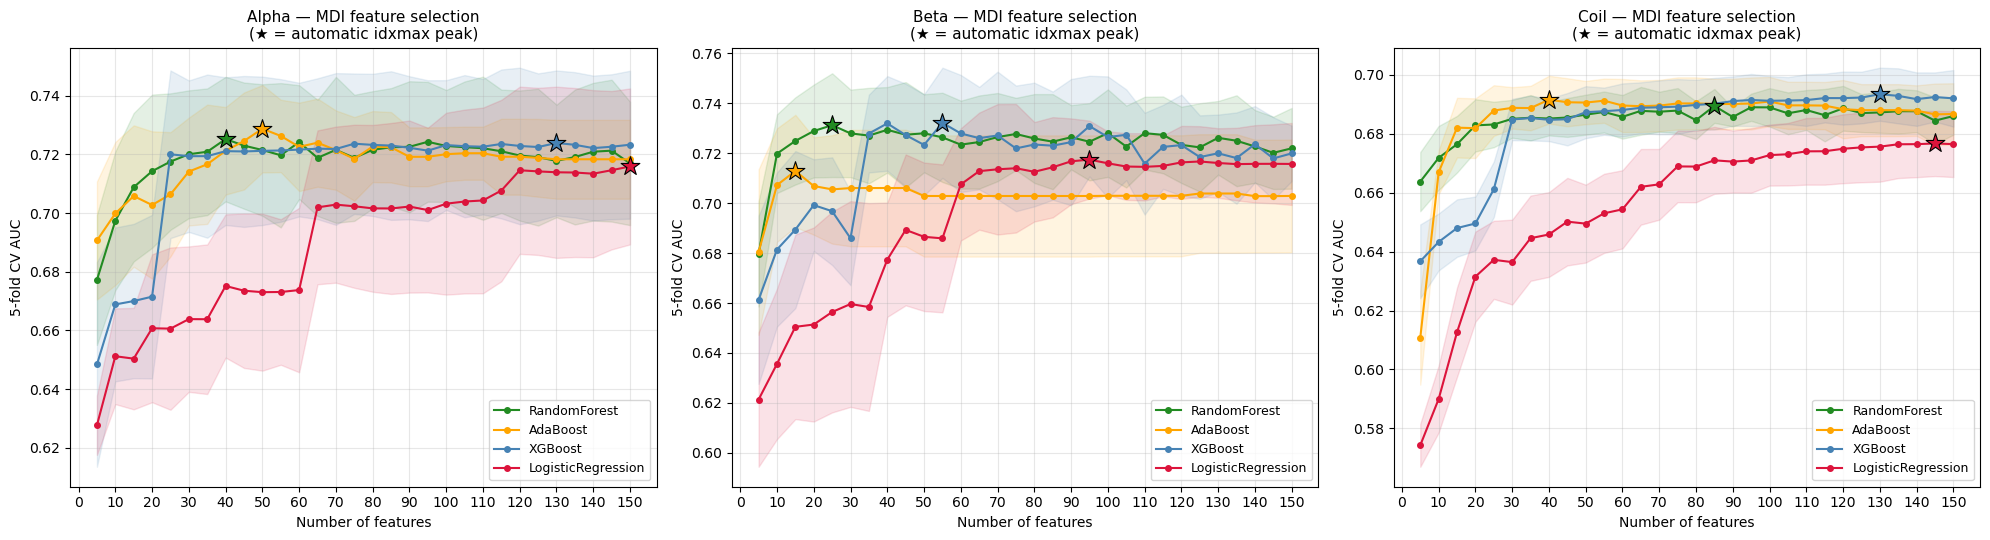


=== Detailed AUC table — read this to pick your n manually ===

── Alpha ────────────────────────────────────────────────────────────
     RandomForest  AdaBoost  XGBoost  LogisticRegression
n                                                       
5          0.6772    0.6907   0.6484              0.6277
10         0.6974    0.6999   0.6689              0.6512
15         0.7088    0.7058   0.6700              0.6504
20         0.7143    0.7028   0.6715              0.6607
25         0.7176    0.7064   0.7200              0.6606
30         0.7201    0.7141   0.7194              0.6639
35         0.7209    0.7166   0.7194              0.6638
40         0.7252    0.7212   0.7211              0.6752
45         0.7230    0.7246   0.7210              0.6735
50         0.7215    0.7287   0.7212              0.6730
55         0.7197    0.7263   0.7213              0.6731
60         0.7242    0.7226   0.7216              0.6738
65         0.7188    0.7240   0.7219              0.7020
70        

In [ ]:
# ── Cell : Compute all 12 (model × subclass) feature-selection curves ──
# Heavy computation: ~20-40 min. Run once, then iterate visually with Cell B.

screening_report = pd.read_csv("/Users/gregoirevandeneynde/Documents/ULB/Q2/Methods_in_bioinformatics/Project/model_screening/screening_report.csv")

SUBCLASS_DATA = {
    'Alpha': (X_train_alpha, y_train_alpha),
    'Beta':  (X_train_beta,  y_train_beta),
    'Coil':  (X_train_coil,  y_train_coil),
}
MODEL_NAMES = ['RandomForest', 'AdaBoost', 'XGBoost', 'LogisticRegression']
N_RANGE     = list(range(5, 151, 5))


def get_best_params(subclass, model_name, report):
    row = report[(report['Subclass'] == subclass) & (report['Model'] == model_name)]
    params_str = row['Best_Params'].values[0]
    return ast.literal_eval(params_str) if isinstance(params_str, str) else params_str


def get_mdi_ranking(model, model_name, feature_names):
    if model_name == "LogisticRegression":
        importances = np.abs(model.coef_[0])
    else:
        importances = model.feature_importances_
    return pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True)


def compute_fs_curve(model_name, subclass, X_train, y_train, feature_names,
                     screening_report, n_range=N_RANGE, cv_folds=5):
    """
    Compute the AUC-vs-n curve WITHOUT making any automatic choice.
    Returns ranking + curves DataFrame. No `best_n` selection here.
    """
    params = get_best_params(subclass, model_name, screening_report)
    
    # Initial fit on full feature set → MDI ranking
    model = init_model(model_name, params)
    model.fit(X_train, y_train)
    ranking = get_mdi_ranking(model, model_name, feature_names)
    
    # Iterative CV on shrinking subsets
    cv         = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    auc_scores = []
    feat_list  = ranking['feature'].tolist()
    
    for n in n_range:
        top_feats = feat_list[:n]
        indices   = [list(feature_names).index(f) for f in top_feats]
        m         = init_model(model_name, params)
        cv_aucs   = cross_val_score(m, X_train[:, indices], y_train,
                                     cv=cv, scoring='roc_auc', n_jobs=4)
        auc_scores.append({
            'n': n, 
            'CV_AUC': np.mean(cv_aucs), 
            'CV_AUC_std': np.std(cv_aucs)
        })
    
    return {
        'subclass': subclass, 'model': model_name,
        'ranking': ranking, 
        'curves': pd.DataFrame(auc_scores),
        'screening_auc_487': screening_report.query(
            "Subclass == @subclass and Model == @model_name"
        )['CV_AUC'].values[0],
    }


# ── Run all 12 combinations ──
all_curves = {}
print("=== Computing feature-selection curves (4 models × 3 subclasses) ===\n")
for subclass, model_name in product(['Alpha', 'Beta', 'Coil'], MODEL_NAMES):
    X_tr, y_tr = SUBCLASS_DATA[subclass]
    print(f"[{subclass} | {model_name}] running…", end=' ', flush=True)
    res = compute_fs_curve(model_name, subclass, X_tr, y_tr,
                            feature_names, screening_report)
    all_curves[(subclass, model_name)] = res
    # Show idxmax just for reference, but no decision is taken
    auto_best = res['curves'].loc[res['curves']['CV_AUC'].idxmax()]
    print(f"AUC peaks at n={int(auto_best['n']):3d} (AUC={auto_best['CV_AUC']:.4f})")


# ── Visualisation with annotated peak ──
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), sharey=False)
colors = {'RandomForest': 'forestgreen', 'AdaBoost': 'orange', 
          'XGBoost': 'steelblue', 'LogisticRegression': 'crimson'}

for ax, subclass in zip(axes, ['Alpha', 'Beta', 'Coil']):
    for model_name in MODEL_NAMES:
        res = all_curves[(subclass, model_name)]
        c   = res['curves']
        ax.plot(c['n'], c['CV_AUC'], marker='o', ms=4,
                color=colors[model_name], label=model_name)
        ax.fill_between(c['n'], c['CV_AUC'] - c['CV_AUC_std'],
                         c['CV_AUC'] + c['CV_AUC_std'], 
                         alpha=0.12, color=colors[model_name])
        # Mark the idxmax peak with a star
        peak = c.loc[c['CV_AUC'].idxmax()]
        ax.scatter(peak['n'], peak['CV_AUC'], marker='*', s=200,
                    color=colors[model_name], edgecolor='black', 
                    linewidth=0.8, zorder=5)
    
    ax.set_title(f"{subclass} — MDI feature selection\n(★ = automatic idxmax peak)", 
                  fontsize=11)
    ax.set_xlabel("Number of features")
    ax.set_ylabel("5-fold CV AUC")
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)
    # Tick every 10 features for easier visual selection
    ax.set_xticks(range(0, 151, 10))
    
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "feature_selection_all_models_mdi.pdf", dpi=150)
plt.show()


# ── Print a tabular view of each curve for easy manual inspection ──
print("\n=== Detailed AUC table — read this to pick your n manually ===")
for subclass in ['Alpha', 'Beta', 'Coil']:
    print(f"\n── {subclass} " + "─" * 60)
    rows = []
    for model_name in MODEL_NAMES:
        c = all_curves[(subclass, model_name)]['curves']
        rows.append(pd.Series(c.set_index('n')['CV_AUC'].round(4), name=model_name))
    print(pd.concat(rows, axis=1).to_string())

=== MDI-winner ===
- Alpha : AdaBoost, 50 features
- Beta : RandomForest, 25 features
- Coil : AdaBoost, 40 features


Now, MDI-features ranking may be biased and innacurate. We will compare the feature selection process for these 3 models with a ranking based on Permutation-importance, which is in principle less prone to bias towards continuous, high cardinality variables such as MDI. 


[Alpha | AdaBoost]
  Computing MDI curve…
  Computing refined ranking…
  Method used: PermutationImportance | computing curve…
  MDI peak    : n= 50, AUC=0.7287
  PermutationImportance peak: n= 35, AUC=0.7359

[Beta | RandomForest]
  Computing MDI curve…
  Computing refined ranking…
  Method used: PermutationImportance | computing curve…
  MDI peak    : n= 25, AUC=0.7313
  PermutationImportance peak: n=150, AUC=0.6905

[Coil | AdaBoost]
  Computing MDI curve…
  Computing refined ranking…
  Method used: PermutationImportance | computing curve…
  MDI peak    : n= 40, AUC=0.6916
  PermutationImportance peak: n= 40, AUC=0.6935


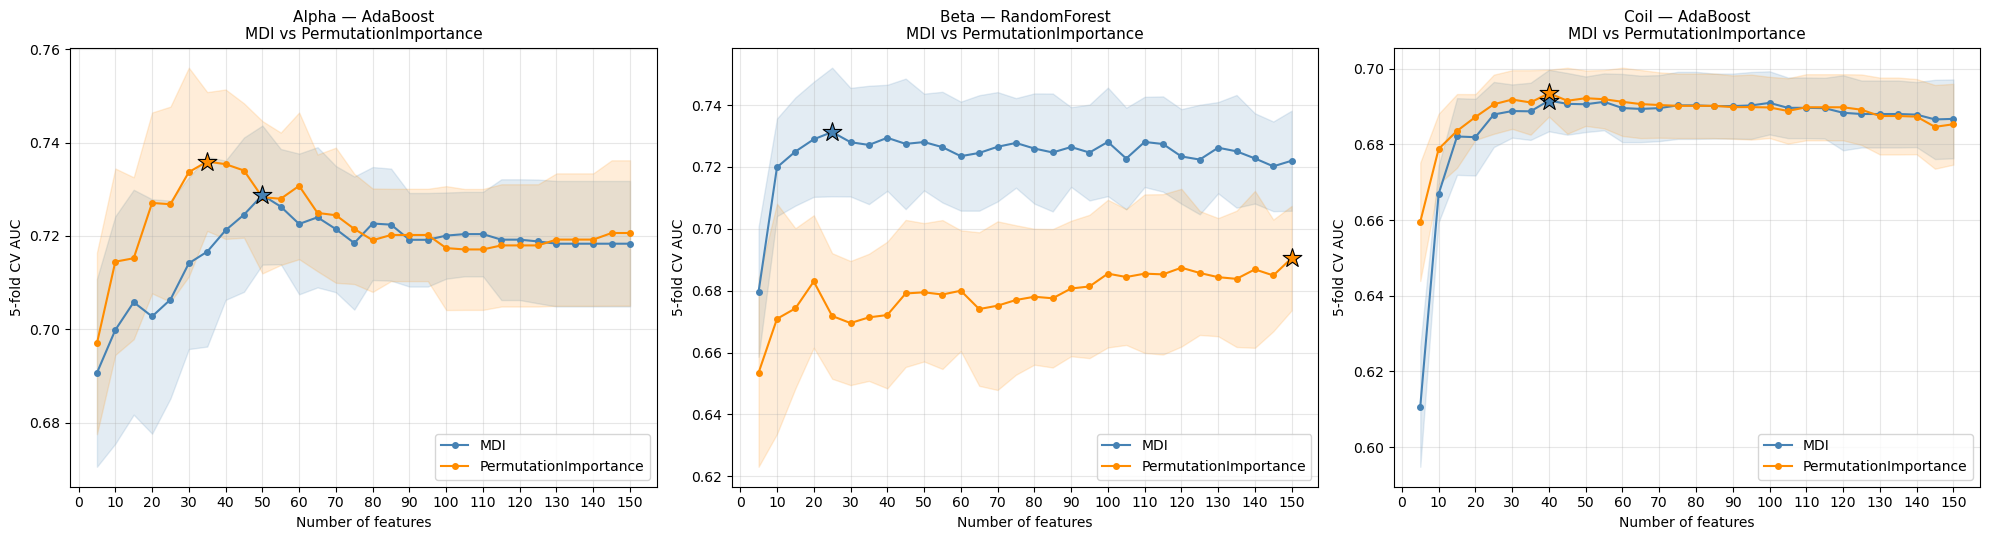


=== RANK SHIFT (top 5 promus / top 5 rétrogradés par méthode raffinée) ===

── Alpha (AdaBoost, PermutationImportance) ──
  Top 5 promus par méthode raffinée (sous-estimés par MDI):
                feature  mdi_rank  ref_rank  delta
             azae970102       905       281    624
      Mw_numeric_values       574        88    486
  Rf_numeric_site_value       455       358     97
El_normalize_site_value       176       120     56
       Esm_numeric_diff       177       122     55
  Top 5 rétrogradés (sur-estimés par MDI):
                  feature  mdi_rank  ref_rank  delta
          dH_numeric_diff        67       929   -862
               MEHP950102        79       928   -849
ZIMJ680101_numeric_values        83       579   -496
  K0_normalize_site_value       609       927   -318
       Hnc_numeric_values       219       472   -253

── Beta (RandomForest, PermutationImportance) ──
  Top 5 promus par méthode raffinée (sous-estimés par MDI):
                 feature  mdi_rank  ref_

In [15]:
# ── Cell : MDI vs Permutation feature selection curves (winners only) ──

from sklearn.inspection import permutation_importance

SUBCLASS_DATA = {
    'Alpha': (X_train_alpha, y_train_alpha),
    'Beta':  (X_train_beta,  y_train_beta),
    'Coil':  (X_train_coil,  y_train_coil),
}

WINNERS = {
    'Alpha': ('AdaBoost',     ),
    'Beta':  ('RandomForest', ),
    'Coil':  ('AdaBoost',     ),
}

N_RANGE = list(range(5, 151, 5))

screening_report = pd.read_csv("/Users/gregoirevandeneynde/Documents/ULB/Q2/Methods_in_bioinformatics/Project/model_screening/screening_report.csv")

def get_refined_ranking(model, model_name, X_train, y_train, feature_names):
    """Permutation importance ranking to compare to MDI."""
    r = permutation_importance(
            model, X_train, y_train,
            n_repeats=3, random_state=42,
            scoring='roc_auc', n_jobs=4)
    
    ranking = pd.DataFrame({
        'feature':    feature_names,
        'importance': r.importances_mean
    }).sort_values('importance', ascending=False).reset_index(drop=True)
    
    return ranking, 'PermutationImportance'


def compute_one_curve(model_name, subclass, X_train, y_train,
                       feature_names, params, ranking, n_range, cv_folds=5):
    """Compute AUC-vs-n for a given pre-computed ranking."""
    cv        = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    feat_list = ranking['feature'].tolist()
    rows      = []
    for n in n_range:
        idx     = [list(feature_names).index(f) for f in feat_list[:n]]
        m       = init_model(model_name, params)
        cv_aucs = cross_val_score(m, X_train[:, idx], y_train,
                                   cv=cv, scoring='roc_auc', n_jobs=4)
        rows.append({'n': n, 'CV_AUC': np.mean(cv_aucs), 
                              'CV_AUC_std': np.std(cv_aucs)})
    return pd.DataFrame(rows)

def get_mdi_ranking(model, model_name, feature_names):
    if model_name == "LogisticRegression":
        importances = np.abs(model.coef_[0])
    else:
        importances = model.feature_importances_
    return pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True)


# ── Compute MDI + refined curves for each winner ──
comparison = {}  # subclass → dict with both curves

for subclass, (model_name,) in WINNERS.items():
    X_tr, y_tr = SUBCLASS_DATA[subclass]
    params     = get_best_params(subclass, model_name, screening_report)
    
    print(f"\n[{subclass} | {model_name}]")
    model = init_model(model_name, params)
    model.fit(X_tr, y_tr)
    
    # MDI ranking + curve
    print("  Computing MDI curve…")
    mdi_ranking  = get_mdi_ranking(model, model_name, feature_names)
    mdi_curve    = compute_one_curve(model_name, subclass, X_tr, y_tr,
                                      feature_names, params, mdi_ranking, N_RANGE)
    
    # SHAP/Permutation ranking + curve
    print("  Computing refined ranking…")
    ref_ranking, method = get_refined_ranking(model, model_name, X_tr, y_tr, feature_names)
    print(f"  Method used: {method} | computing curve…")
    ref_curve    = compute_one_curve(model_name, subclass, X_tr, y_tr,
                                      feature_names, params, ref_ranking, N_RANGE)
    
    comparison[subclass] = {
        'model':       model_name,
        'method':      method,
        'mdi_ranking': mdi_ranking,
        'ref_ranking': ref_ranking,
        'mdi_curve':   mdi_curve,
        'ref_curve':   ref_curve,
    }
    
    mdi_peak = mdi_curve.loc[mdi_curve['CV_AUC'].idxmax()]
    ref_peak = ref_curve.loc[ref_curve['CV_AUC'].idxmax()]
    print(f"  MDI peak    : n={int(mdi_peak['n']):3d}, AUC={mdi_peak['CV_AUC']:.4f}")
    print(f"  {method} peak: n={int(ref_peak['n']):3d}, AUC={ref_peak['CV_AUC']:.4f}")


# ── Plot : 1 graphe par sous-classe, 2 courbes ──
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), sharey=False)

for ax, subclass in zip(axes, ['Alpha', 'Beta', 'Coil']):
    c = comparison[subclass]
    
    for curve, color, label in [
        (c['mdi_curve'], 'steelblue', 'MDI'),
        (c['ref_curve'], 'darkorange', c['method']),
    ]:
        ax.plot(curve['n'], curve['CV_AUC'], 'o-', ms=4,
                color=color, label=label)
        ax.fill_between(curve['n'],
                         curve['CV_AUC'] - curve['CV_AUC_std'],
                         curve['CV_AUC'] + curve['CV_AUC_std'],
                         alpha=0.15, color=color)
        # Mark peak
        peak = curve.loc[curve['CV_AUC'].idxmax()]
        ax.scatter(peak['n'], peak['CV_AUC'], marker='*', s=200,
                    color=color, edgecolor='black', linewidth=0.8, zorder=5)
    
    ax.set_title(f"{subclass} — {c['model']}\nMDI vs {c['method']}", fontsize=11)
    ax.set_xlabel("Number of features")
    ax.set_ylabel("5-fold CV AUC")
    ax.set_xticks(range(0, 151, 10))
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_PATH / "mdi_vs_refined_comparison.pdf", dpi=150)
plt.show()


# ── Rank shift : top features promus/rétrogradés par la méthode raffinée ──
print("\n=== RANK SHIFT (top 5 promus / top 5 rétrogradés par méthode raffinée) ===")
for subclass, c in comparison.items():
    mdi = c['mdi_ranking'].reset_index().rename(columns={'index': 'mdi_rank'})
    ref = c['ref_ranking'].reset_index().rename(columns={'index': 'ref_rank'})
    merged = pd.merge(mdi[['feature','mdi_rank']], 
                       ref[['feature','ref_rank']], on='feature')
    merged['delta'] = merged['mdi_rank'] - merged['ref_rank']  # + = promu par refined
    
    print(f"\n── {subclass} ({c['model']}, {c['method']}) ──")
    print("  Top 5 promus par méthode raffinée (sous-estimés par MDI):")
    print(merged.nlargest(5, 'delta')[['feature','mdi_rank','ref_rank','delta']].to_string(index=False))
    print("  Top 5 rétrogradés (sur-estimés par MDI):")
    print(merged.nsmallest(5, 'delta')[['feature','mdi_rank','ref_rank','delta']].to_string(index=False))



=== Compare beta ranking with SHAP as well (ShapExplainer not compatible with AdaBoost, so we cannot use it for alpha and coil)

sv type: <class 'numpy.ndarray'>, shape: (1544, 930, 2)
importances shape: (930,), feature_names len: 930
Computing MDI curve…
Computing SHAP curve…
MDI peak: n=25, AUC=0.7313
SHAP peak: n=105, AUC=0.7221


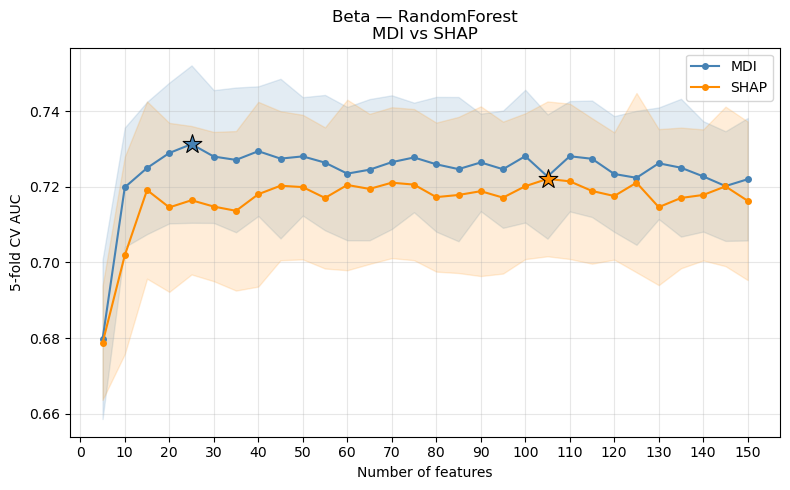

In [13]:
# ── Beta only : MDI vs SHAP (RandomForest → TreeExplainer exact) ──

X_tr, y_tr = X_train_beta, y_train_beta
params      = get_best_params('Beta', 'RandomForest', screening_report)

# Fit once
model = init_model('RandomForest', params)
model.fit(X_tr, y_tr)

# MDI ranking
mdi_ranking = get_mdi_ranking(model, 'RandomForest', feature_names)

# SHAP ranking
explainer = shap.TreeExplainer(model)
sv        = explainer.shap_values(X_tr)

# Gestion des différents formats selon la version de SHAP
print(f"sv type: {type(sv)}, shape: {np.array(sv).shape}")
if isinstance(sv, list):
    sv = sv[1]                  # ancienne version : liste [class0, class1]
elif len(sv.shape) == 3:
    sv = sv[:, :, 1]            # nouvelle version : (n_samples, n_features, n_classes)
# sv est maintenant forcément 2D : (n_samples, n_features)

importances = np.abs(sv).mean(axis=0)  # 1D : (n_features,)
print(f"importances shape: {importances.shape}, feature_names len: {len(feature_names)}")

shap_ranking = pd.DataFrame({
    'feature':    feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Curves
print("Computing MDI curve…")
mdi_curve  = compute_one_curve('RandomForest', 'Beta', X_tr, y_tr,
                                feature_names, params, mdi_ranking,  N_RANGE)
print("Computing SHAP curve…")
shap_curve = compute_one_curve('RandomForest', 'Beta', X_tr, y_tr,
                                feature_names, params, shap_ranking, N_RANGE)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
for curve, color, label in [
    (mdi_curve,  'steelblue',  'MDI'),
    (shap_curve, 'darkorange', 'SHAP'),
]:
    ax.plot(curve['n'], curve['CV_AUC'], 'o-', ms=4, color=color, label=label)
    ax.fill_between(curve['n'],
                     curve['CV_AUC'] - curve['CV_AUC_std'],
                     curve['CV_AUC'] + curve['CV_AUC_std'],
                     alpha=0.15, color=color)
    peak = curve.loc[curve['CV_AUC'].idxmax()]
    ax.scatter(peak['n'], peak['CV_AUC'], marker='*', s=200,
                color=color, edgecolor='black', linewidth=0.8, zorder=5)
    print(f"{label} peak: n={int(peak['n'])}, AUC={peak['CV_AUC']:.4f}")

ax.set_title("Beta — RandomForest\nMDI vs SHAP")
ax.set_xlabel("Number of features")
ax.set_ylabel("5-fold CV AUC")
ax.set_xticks(range(0, 151, 10))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "beta_mdi_vs_shap.pdf", dpi=150)
plt.show()

SHAP rankings does not seem better than MDI here. We keep thee best models found before :
- Alpha : AdaBoost, 35 features identified by permutation importance
- Beta : RF, 25 features identified by MDI
- Coil : AdaBoost, 40 features identified by permutation importance

In [ ]:
# ── Cell : Save all results to disk ──
import pickle, json
from pathlib import Path

SAVE_DIR = Path("outputs/feature_selection_results")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# 1. Full saving
with open(SAVE_DIR / "comparison.pkl", "wb") as f:
    pickle.dump(comparison, f)
print("✓ comparison.pkl saved")

# 2. Ranking saving in csv
for subclass, c in comparison.items():
    c['mdi_ranking'].to_csv(
        SAVE_DIR / f"ranking_mdi_{subclass}.csv", index=False)
    c['ref_ranking'].to_csv(
        SAVE_DIR / f"ranking_perm_{subclass}.csv", index=False)
    c['mdi_curve'].to_csv(
        SAVE_DIR / f"curve_mdi_{subclass}.csv", index=False)
    c['ref_curve'].to_csv(
        SAVE_DIR / f"curve_perm_{subclass}.csv", index=False)
print("✓ Rankings + curves saved as CSV")

# 3. Final choices for model
FINAL_CHOICES = {
    'Alpha': {'model': 'AdaBoost',     'n': 35, 'ranking': 'Permutation'},
    'Beta':  {'model': 'RandomForest', 'n': 25, 'ranking': 'MDI'},  
    'Coil':  {'model': 'AdaBoost',     'n': 40, 'ranking': 'Permutation'},
}
with open(SAVE_DIR / "final_choices.json", "w") as f:
    json.dump(FINAL_CHOICES, f, indent=2)
print("✓ final_choices.json saved")

# 4. Winner construction
final_winners = {}
for subclass, choice in FINAL_CHOICES.items():
    c           = comparison[subclass]
    ranking_key = 'mdi_ranking' if choice['ranking'] == 'MDI' else 'ref_ranking'
    top_feats   = c[ranking_key]['feature'].head(choice['n']).tolist()
    
    final_winners[subclass] = {
        'model':    choice['model'],
        'n':        choice['n'],
        'ranking':  choice['ranking'],
        'features': top_feats,
        'params':   get_best_params(subclass, choice['model'], screening_report),
    }
    print(f"  {subclass}: {choice['model']}, n={choice['n']} "
          f"({choice['ranking']}) | top 3: {top_feats[:3]}")

# 5. Save winner
with open(SAVE_DIR / "final_winners.pkl", "wb") as f:
    pickle.dump(final_winners, f)
print("\n✓ final_winners.pkl saved — pipeline ready to continue")

✓ comparison.pkl saved
✓ Rankings + curves saved as CSV
✓ final_choices.json saved
  Alpha: AdaBoost, n=35 (Permutation) | top 3: [' rsa', 'YUTK870102_numeric_site_value', 'Br_numeric_diff']
  Beta: RandomForest, n=25 (MDI) | top 3: [' rsa', 'RISJ880101', 'risj880101']
  Coil: AdaBoost, n=40 (Permutation) | top 3: [' rsa', 'aN_numeric_site_value', 'dG_normalize_diff']

✓ final_winners.pkl saved — pipeline ready to continue


In [14]:
# ── Cell : Reload after kernel restart ──
import pickle, json
from pathlib import Path

SAVE_DIR = Path("outputs/feature_selection_results")

with open(SAVE_DIR / "comparison.pkl", "rb") as f:
    comparison = pickle.load(f)

with open(SAVE_DIR / "final_winners.pkl", "rb") as f:
    final_winners = pickle.load(f)

print("✓ comparison + final_winners rechargés")
for sc, w in final_winners.items():
    print(f"  {sc}: {w['model']}, n={w['n']} ({w['ranking']})")

✓ comparison + final_winners rechargés
  Alpha: AdaBoost, n=35 (Permutation)
  Beta: RandomForest, n=25 (MDI)
  Coil: AdaBoost, n=40 (Permutation)


=== Hyperparameter optimisation on the selected models with appropriate number of features ===

In [51]:
# ── Cell : Re-tune on selected features + final fit ──
# NO test set used here — CV only.

SUBCLASS_DATA = {
    'Alpha': (X_train_alpha, y_train_alpha),
    'Beta':  (X_train_beta,  y_train_beta),
    'Coil':  (X_train_coil,  y_train_coil),
}

final_models = {}

for subclass, winner in final_winners.items():
    print(f"\n── {subclass} | {winner['model']} | n={winner['n']} ──")
    
    X_tr, y_tr = SUBCLASS_DATA[subclass]
    feat_idx   = [list(feature_names).index(f) for f in winner['features']]
    X_sub      = X_tr[:, feat_idx]
    
    # Re-tune via CV
    cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    search = RandomizedSearchCV(
        init_model(winner['model'], winner['params']),
        param_grids[winner['model']],
        n_iter=50, cv=cv, scoring='roc_auc',
        n_jobs=4, random_state=42
    )
    search.fit(X_sub, y_tr)
    print(f"  CV AUC after  retune : {search.best_score_:.4f}")
    print(f"  Best params : {search.best_params_}")
    
    # Final fit on full train set with best params
    final_model = init_model(winner['model'], search.best_params_)
    final_model.fit(X_sub, y_tr)
    final_models[subclass] = final_model
    
    # Save
    joblib.dump(final_model, f"outputs/model_{subclass.lower()}.pkl")
    print(f"  ✓ model_{subclass.lower()}.pkl saved")


── Alpha | AdaBoost | n=35 ──


/Users/gregoirevandeneynde/opt/anaconda3/envs/hemo_env/lib/python3.9/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=50. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/Users/gregoirevandeneynde/opt/anaconda3/envs/hemo_env/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/gregoirevandeneynde/opt/anaconda3/envs/hemo_env/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/gregoirevandeneynde/opt/anaconda3/envs/hemo_env/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. I

  CV AUC after  retune : 0.7359
  Best params : {'n_estimators': 200, 'learning_rate': 1.0, 'algorithm': 'SAMME'}


/Users/gregoirevandeneynde/opt/anaconda3/envs/hemo_env/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


  ✓ model_alpha.pkl saved

── Beta | RandomForest | n=25 ──
  CV AUC after  retune : 0.7316
  Best params : {'n_estimators': 500, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': None}
  ✓ model_beta.pkl saved

── Coil | AdaBoost | n=40 ──


/Users/gregoirevandeneynde/opt/anaconda3/envs/hemo_env/lib/python3.9/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=50. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/Users/gregoirevandeneynde/opt/anaconda3/envs/hemo_env/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/gregoirevandeneynde/opt/anaconda3/envs/hemo_env/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/gregoirevandeneynde/opt/anaconda3/envs/hemo_env/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. I

  CV AUC after  retune : 0.6935
  Best params : {'n_estimators': 200, 'learning_rate': 1.0, 'algorithm': 'SAMME'}


/Users/gregoirevandeneynde/opt/anaconda3/envs/hemo_env/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


  ✓ model_coil.pkl saved


---
##  TEST SET — used her
First we optimise a decision threshold (by opitmising Balanced Accuracy on the TRAIN-test); then we evaluate final model peformances on the test set with the optimal threshold.
Once we start eavluating on the test set, no more modifications or decisions are make. 

In [52]:
# ── Cell : Threshold optimisation + Final evaluation on test set ──
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import cross_val_predict

SUBCLASS_TEST = {
    'Alpha': (X_test_alpha, y_test_alpha),
    'Beta':  (X_test_beta,  y_test_beta),
    'Coil':  (X_test_coil,  y_test_coil),
}

def find_optimal_threshold_cv(model, X_train, y_train, feat_idx, cv_folds=5):
    """
    Threshold optimisation via out-of-fold probabilities (cross_val_predict).
    """
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    
    # Probas out-of-fold : chaque observation prédite par un modèle qui ne l'a pas vue
    oof_proba = cross_val_predict(
        model, X_train[:, feat_idx], y_train,
        cv=cv, method='predict_proba', n_jobs=-1
    )[:, 1]
    
    fpr, tpr, thresholds = roc_curve(y_train, oof_proba)
    bal_acc  = (tpr + (1 - fpr)) / 2
    best_idx = np.argmax(bal_acc)
    best_thr = thresholds[best_idx]
    
    print(f"  OOF BalAcc at optimal threshold {best_thr:.4f} : {bal_acc[best_idx]:.4f} "
          f"(vs default 0.5 : {balanced_accuracy_score(y_train, oof_proba >= 0.5):.4f})")
    return best_thr


test_results = []

for subclass, winner in final_winners.items():
    print(f"\n── {subclass} | {winner['model']} ──")
    X_tr, y_tr = SUBCLASS_DATA[subclass]
    X_te, y_te = SUBCLASS_TEST[subclass]
    feat_idx   = [list(feature_names).index(f) for f in winner['features']]
    
    # 1. Threshold optimisation via OOF CV sur train set
    best_thr = find_optimal_threshold_cv(
        final_models[subclass], X_tr, y_tr, feat_idx
    )
    
    # 2. Prédictions sur test set avec ce threshold
    y_proba = final_models[subclass].predict_proba(X_te[:, feat_idx])[:, 1]
    y_pred  = (y_proba >= best_thr).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
    test_results.append({
        'Subclass':    subclass,
        'Model':       winner['model'],
        'N_features':  winner['n'],
        'Threshold':   round(best_thr, 4),
        'ND':          int((y_te == 1).sum()),
        'NP':          int((y_te == 0).sum()),
        'Sensitivity': round(tp / (tp + fn) * 100, 2),
        'Specificity': round(tn / (tn + fp) * 100, 2),
        'Accuracy':    round((tp + tn) / (tp + tn + fp + fn) * 100, 2),
        'Bal_Accuracy':round(balanced_accuracy_score(y_te, y_pred) * 100, 2),
        'MCC':         round(matthews_corrcoef(y_te, y_pred), 3),
        'AUC':         round(roc_auc_score(y_te, y_proba), 3),
        'y_true':      y_te,
        'y_proba':     y_proba,
    })

# ── Overall : threshold OOF sur tout le train set combiné ──
all_y_tr     = np.concatenate([SUBCLASS_DATA[sc][1] for sc in final_winners])
all_proba_oof = np.concatenate([
    cross_val_predict(
        final_models[sc],
        SUBCLASS_DATA[sc][0][:, [list(feature_names).index(f)
                                  for f in final_winners[sc]['features']]],
        SUBCLASS_DATA[sc][1],
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        method='predict_proba', n_jobs=-1
    )[:, 1]
    for sc in final_winners
])
fpr_all, tpr_all, thr_all = roc_curve(all_y_tr, all_proba_oof)
best_thr_overall = thr_all[np.argmax((tpr_all + (1 - fpr_all)) / 2)]

all_y_true  = np.concatenate([r['y_true']  for r in test_results])
all_y_proba = np.concatenate([r['y_proba'] for r in test_results])
all_y_pred  = (all_y_proba >= best_thr_overall).astype(int)

tn, fp, fn, tp = confusion_matrix(all_y_true, all_y_pred).ravel()
test_results.append({
    'Subclass':    'Overall',
    'Model':       '—',
    'N_features':  '—',
    'Threshold':   round(best_thr_overall, 4),
    'ND':          int((all_y_true == 1).sum()),   # ← même clé que les sous-classes
    'NP':          int((all_y_true == 0).sum()),   # ← idem
    'Sensitivity': round(tp / (tp + fn) * 100, 2),
    'Specificity': round(tn / (tn + fp) * 100, 2),
    'Accuracy':    round((tp + tn) / (tp + tn + fp + fn) * 100, 2),
    'Bal_Accuracy':round(balanced_accuracy_score(all_y_true, all_y_pred) * 100, 2),
    'MCC':         round(matthews_corrcoef(all_y_true, all_y_pred), 3),
    'AUC':         round(roc_auc_score(all_y_true, all_y_proba), 3),
    'y_true':      all_y_true,
    'y_proba':     all_y_proba,
})

# Display
results_df = pd.DataFrame(test_results).drop(columns=['y_true', 'y_proba'])
print("\n=== TEST SET RESULTS ===")
print(results_df.to_string(index=False))
results_df.to_csv("outputs/test_results.csv", index=False)


── Alpha | AdaBoost ──


/Users/gregoirevandeneynde/opt/anaconda3/envs/hemo_env/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/gregoirevandeneynde/opt/anaconda3/envs/hemo_env/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/gregoirevandeneynde/opt/anaconda3/envs/hemo_env/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/gregoirevandeneynde/opt/anaconda3/envs/hemo_env/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed i

  OOF BalAcc at optimal threshold 0.5164 : 0.6764 (vs default 0.5 : 0.6633)

── Beta | RandomForest ──
  OOF BalAcc at optimal threshold 0.5240 : 0.6748 (vs default 0.5 : 0.6670)

── Coil | AdaBoost ──


/Users/gregoirevandeneynde/opt/anaconda3/envs/hemo_env/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/gregoirevandeneynde/opt/anaconda3/envs/hemo_env/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/gregoirevandeneynde/opt/anaconda3/envs/hemo_env/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/gregoirevandeneynde/opt/anaconda3/envs/hemo_env/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed i

  OOF BalAcc at optimal threshold 0.4962 : 0.6447 (vs default 0.5 : 0.6433)


/Users/gregoirevandeneynde/opt/anaconda3/envs/hemo_env/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/gregoirevandeneynde/opt/anaconda3/envs/hemo_env/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/gregoirevandeneynde/opt/anaconda3/envs/hemo_env/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/gregoirevandeneynde/opt/anaconda3/envs/hemo_env/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed i


=== TEST SET RESULTS ===
Subclass        Model N_features  Threshold   ND   NP  Sensitivity  Specificity  Accuracy  Bal_Accuracy   MCC   AUC
   Alpha     AdaBoost         35     0.5164  360  483        57.50        66.05     62.40         61.77 0.235 0.681
    Beta RandomForest         25     0.5240  200  187        78.00        60.96     69.77         69.48 0.396 0.792
    Coil     AdaBoost         40     0.4962  675 1478        63.41        67.52     66.23         65.47 0.291 0.722
 Overall            —          —     0.5000 1235 2148        67.29        64.29     65.39         65.79 0.305 0.730


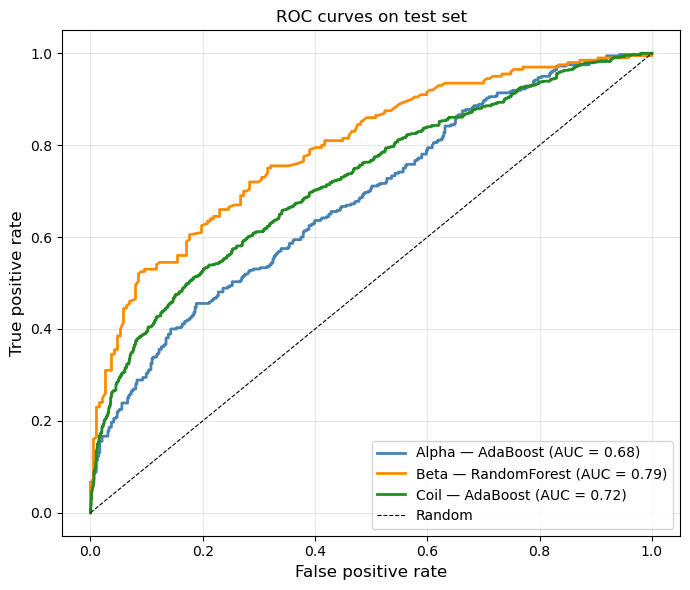

In [54]:
# ── Cell :  test set ROC curves per subclass (replicates Figure 1 of article) ──

fig, ax = plt.subplots(figsize=(7, 6))
colors  = {'Alpha': 'steelblue', 'Beta': 'darkorange', 'Coil': 'forestgreen'}

for r in test_results:
    if r['Subclass'] == 'Overall': continue
    fpr, tpr, _ = roc_curve(r['y_true'], r['y_proba'])
    ax.plot(fpr, tpr, color=colors[r['Subclass']], linewidth=2,
            label=f"{r['Subclass']} — {r['Model']} (AUC = {r['AUC']:.2f})")
    

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random')
ax.set_xlabel("False positive rate", fontsize=12)
ax.set_ylabel("True positive rate", fontsize=12)
ax.set_title("ROC curves on test set")
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "roc_curves_test.pdf", dpi=150)
plt.show()


=== Alpha ===


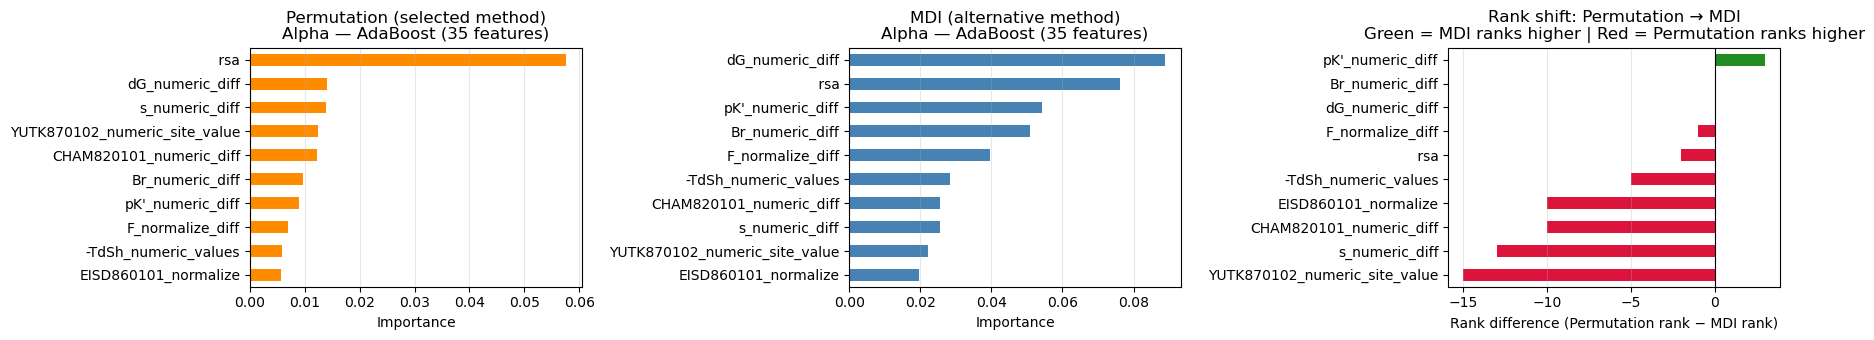


[Alpha] Top 5 rank shifts:
                               Permutation_rank  MDI_rank  rank_delta
YUTK870102_numeric_site_value                 4        19         -15
s_numeric_diff                                3        16         -13
CHAM820101_numeric_diff                       5        15         -10
EISD860101_normalize                         10        20         -10
-TdSh_numeric_values                          9        14          -5

=== Beta ===


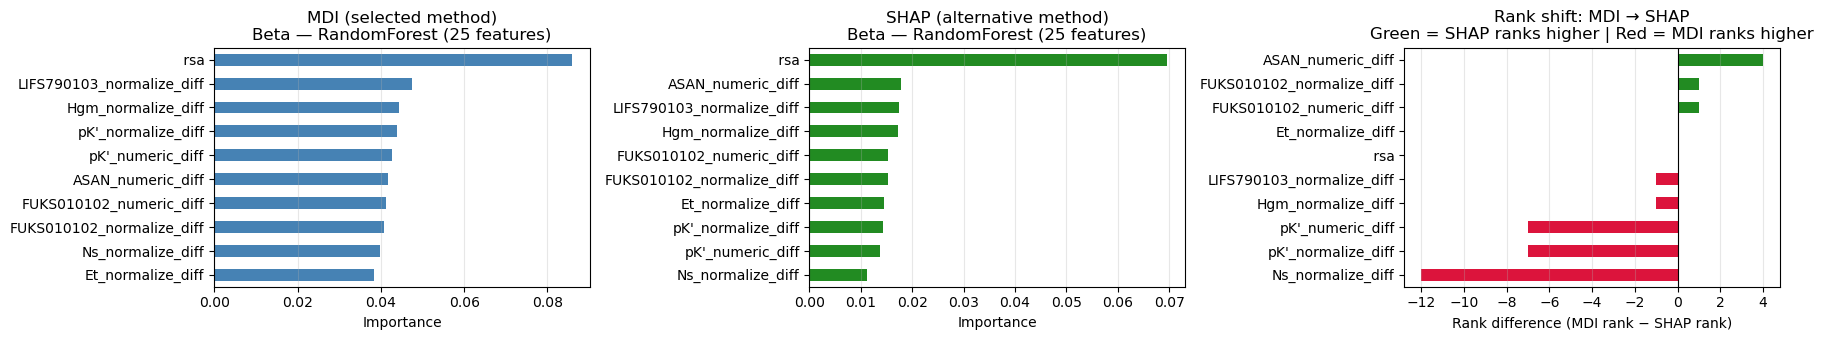


[Beta] Top 5 rank shifts:
                    MDI_rank  SHAP_rank  rank_delta
Ns_normalize_diff          9         21         -12
pK'_normalize_diff         4         11          -7
pK'_numeric_diff           5         12          -7
ASAN_numeric_diff          6          2           4
Hgm_normalize_diff         3          4          -1

=== Coil ===


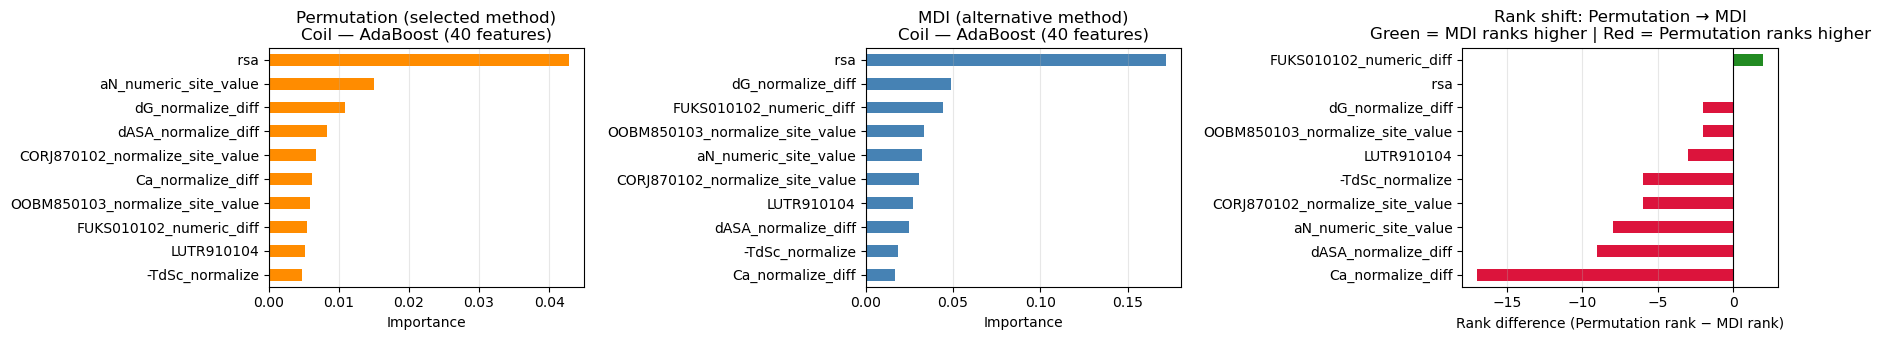


[Coil] Top 5 rank shifts:
                                 Permutation_rank  MDI_rank  rank_delta
Ca_normalize_diff                               6        23         -17
dASA_normalize_diff                             4        13          -9
aN_numeric_site_value                           2        10          -8
CORJ870102_normalize_site_value                 5        11          -6
-TdSc_normalize                                10        16          -6


In [60]:
def plot_importance_comparison_final(subclass, winner, final_model, top_n=10):

    X_tr, y_tr = SUBCLASS_DATA[subclass]
    feat_idx   = [list(feature_names).index(f) for f in winner['features']]
    X_sub      = X_tr[:, feat_idx]
    feat_names = winner['features']

    # ── Calcul MDI ──
    mdi = pd.Series(final_model.feature_importances_, index=feat_names)

    # ── Calcul Permutation ──
    r    = permutation_importance(final_model, X_sub, y_tr,
                                   n_repeats=10, random_state=42,
                                   scoring='roc_auc', n_jobs=-1)
    perm = pd.Series(r.importances_mean, index=feat_names)

    # ── Calcul SHAP (Beta/RF only) ──
    if subclass == 'Beta':
        explainer = shap.TreeExplainer(final_model)
        sv        = explainer.shap_values(X_sub)
        if isinstance(sv, list):    sv = sv[1]
        elif len(sv.shape) == 3:    sv = sv[:, :, 1]
        shap_imp  = pd.Series(np.abs(sv).mean(axis=0), index=feat_names)

    # ── Définition selected vs alternative selon le texte ──
    if subclass == 'Beta':
        # selected = MDI, alternative = SHAP
        selected_imp,  selected_name,  selected_color  = mdi,  'MDI',         'steelblue'
        alternative_imp, alt_name,     alt_color       = shap_imp, 'SHAP',    'forestgreen'
    else:
        # selected = Permutation, alternative = MDI
        selected_imp,  selected_name,  selected_color  = perm, 'Permutation', 'darkorange'
        alternative_imp, alt_name,     alt_color       = mdi,  'MDI',         'steelblue'

    # ── Top N par méthode sélectionnée ──
    top_feats = selected_imp.sort_values(ascending=False).head(top_n).index.tolist()

    df = pd.DataFrame({
        selected_name:  selected_imp[top_feats],
        alt_name:       alternative_imp[top_feats],
    })
    df['selected_rank'] = selected_imp.rank(ascending=False).astype(int)[top_feats]
    df['alt_rank']      = alternative_imp.rank(ascending=False).astype(int)[top_feats]
    # rank_delta > 0 : alternative ranks feature higher than selected
    df['rank_delta']    = df['selected_rank'] - df['alt_rank']

    # ── Plot ──
    fig, axes = plt.subplots(1, 3, figsize=(18, 3.5))
    title = f"{subclass} — {winner['model']} ({winner['n']} features)"

    # Subplot 1 : méthode sélectionnée
    df[selected_name].sort_values().plot(
        kind='barh', ax=axes[0], color=selected_color)
    axes[0].set_title(f"{selected_name} (selected method)\n{title}")
    axes[0].set_xlabel("Importance")
    axes[0].grid(alpha=0.3, axis='x')

    # Subplot 2 : méthode alternative
    df[alt_name].sort_values().plot(
        kind='barh', ax=axes[1], color=alt_color)
    axes[1].set_title(f"{alt_name} (alternative method)\n{title}")
    axes[1].set_xlabel("Importance")
    axes[1].grid(alpha=0.3, axis='x')

    # Subplot 3 : rank shift
    delta_sorted = df['rank_delta'].sort_values()
    colors = ['forestgreen' if x > 0 else 'crimson' for x in delta_sorted]
    delta_sorted.plot(kind='barh', ax=axes[2], color=colors)
    axes[2].axvline(0, color='black', linewidth=0.8)
    axes[2].set_title(
        f"Rank shift: {selected_name} → {alt_name}\n"
        f"Green = {alt_name} ranks higher | Red = {selected_name} ranks higher"
    )
    axes[2].set_xlabel(f"Rank difference ({selected_name} rank − {alt_name} rank)")
    axes[2].grid(alpha=0.3, axis='x')

    plt.tight_layout()
    plt.savefig(OUTPUT_PATH / f"importance_final_{subclass}.pdf",
                dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n[{subclass}] Top 5 rank shifts:")
    print(df[['selected_rank', 'alt_rank', 'rank_delta']]
          .rename(columns={'selected_rank': f'{selected_name}_rank',
                           'alt_rank':      f'{alt_name}_rank'})
          .sort_values('rank_delta', key=abs, ascending=False)
          .head(5).to_string())


# ── Run ──
for subclass, winner in final_winners.items():
    print(f"\n=== {subclass} ===")
    plot_importance_comparison_final(subclass, winner, final_models[subclass])

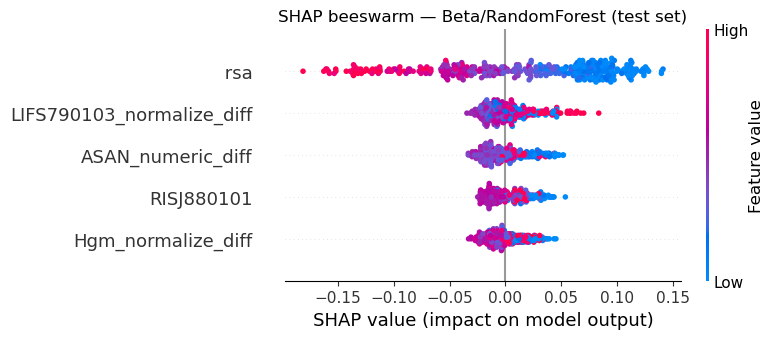

In [58]:
# ── Cell : SHAP beeswarm plot (SHAP interpreation, directional) — Beta/RandomForest on test set ──

feat_idx  = [list(feature_names).index(f) for f in final_winners['Beta']['features']]
X_te_beta = X_test_beta[:, feat_idx]
feat_names_beta = final_winners['Beta']['features']

# Compute SHAP values on test set
explainer = shap.TreeExplainer(final_models['Beta'])
sv        = explainer.shap_values(X_te_beta)
if isinstance(sv, list):    sv = sv[1]
elif len(sv.shape) == 3:    sv = sv[:, :, 1]

# Beeswarm
X_te_df = pd.DataFrame(X_te_beta, columns=feat_names_beta)

plt.figure(figsize=(7, 5))
shap.summary_plot(sv, X_te_df, plot_type='dot', max_display = 5, show=False)
plt.title("SHAP beeswarm — Beta/RandomForest (test set)", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "shap_beeswarm_beta.pdf", dpi=150)
plt.show()